SIC through A pssing between B & D2
D2 dominated, choice_c2:  [0.2504365 0.499127  0.2504365]
D1 perceived similar to A, choice_c1:  [0.30978903 0.61741827 0.0727927 ]
SIC through A pssing between B & D2
D2 dominated, choice_c2:  [0.27688522 0.48207034 0.24104444]
D1 perceived similar to A, choice_c1:  [0.3358431  0.58471881 0.07943809]
SIC through A pssing between B & D2
D2 dominated, choice_c2:  [0.30528193 0.46367517 0.23104289]
D1 perceived similar to A, choice_c1:  [0.36271728 0.55091041 0.08637231]
SIC through A pssing between B & D2
D2 dominated, choice_c2:  [0.3355495  0.44398822 0.22046228]
D1 perceived similar to A, choice_c1:  [0.39017984 0.51627333 0.09354682]
SIC through A pssing between B & D2
D2 dominated, choice_c2:  [0.3675561  0.42309299 0.20935091]
D1 perceived similar to A, choice_c1:  [0.41797036 0.48112473 0.10090492]
SIC through B pssing between A & D1
D1 dominated, choice_c1:  [0.44580827 0.44580827 0.10838345]
D2 perceived similar to B, choice_c2:  [0.40111209 

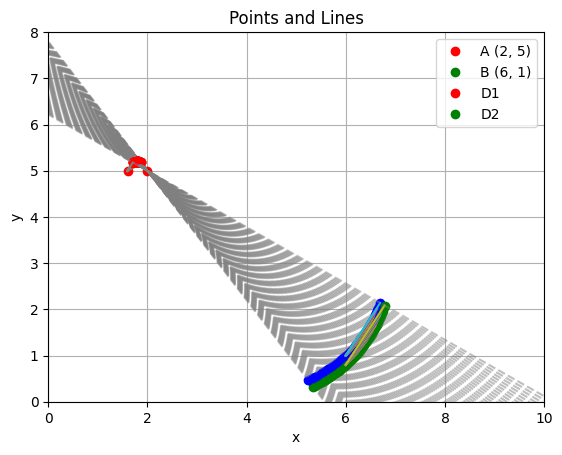

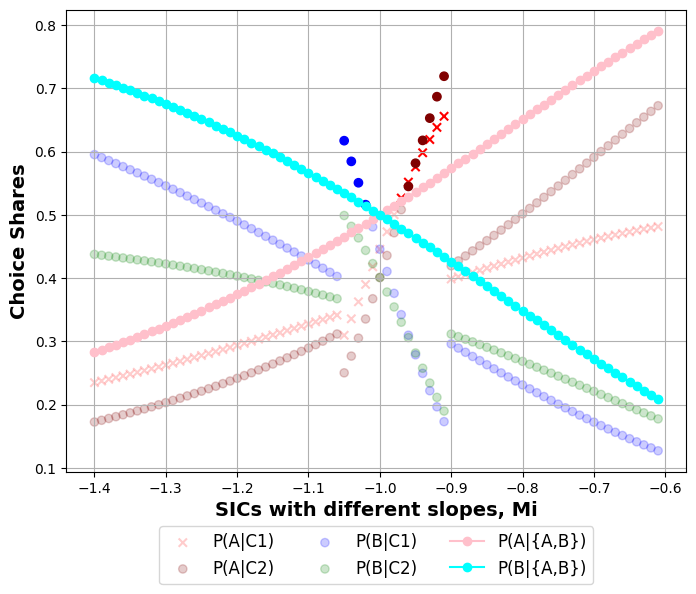

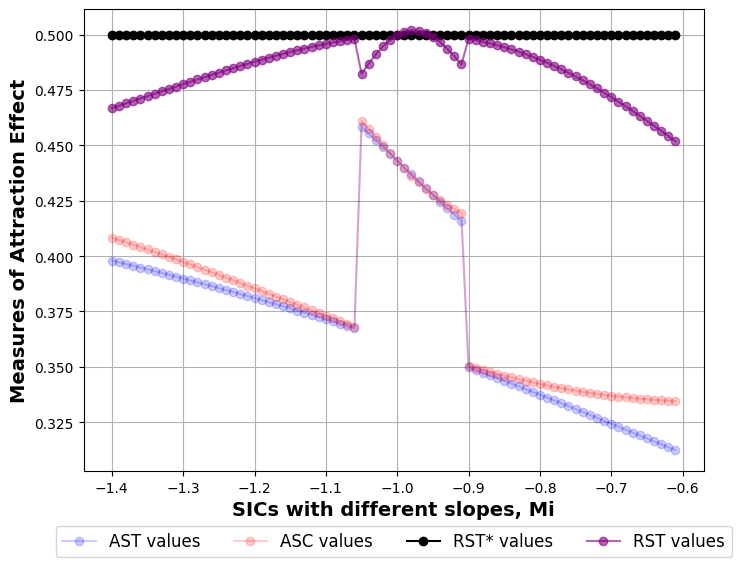

In [1]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

#def softmax(x):
    #e_x = np.exp(x - np.max(x))
    #return e_x / e_x.sum()
beta = 1
def softmax(x):
    e_x = np.exp((x - np.max(x)) * beta)
    return e_x / e_x.sum()

def perpendicular_foot(Px, Py, Ox, Oy, m): # Foot of the perpendicular from point P to line with slope m and passing through O
    Px_, Py_ = sp.symbols('Px_ Py_')
    
    eq1 = sp.Eq(Py - Py_, (-1/m) * (Px - Px_))
    eq2 = sp.Eq(Oy - Py_, m * (Ox - Px_))
    
    solution = sp.solve((eq1, eq2), (Px_, Py_))
    
    return float(solution[Px_]), float(solution[Py_])

def signed_l(Ax,Ay,Bx,By):
    # Calculate the distance between the points
    l = np.sqrt((Ax - Bx)**2 + (Ay - By)**2)

    # Calculate the signed length based on the formula
    if (Ax - Bx) != 0:
        signed_l = l * (Ax - Bx) / np.abs(Ax - Bx)
    else:
        signed_l = 0
    return signed_l

# Given points
Ax, Ay = 2, 5
Bx, By = 6, 1

# Calculate Me (slope of AB)
Me = (Ay - By) / (Ax - Bx)

Mi_values = np.arange(Me - 0.8, Me + 0.9, 0.1)

# Plotting
plt.plot(Ax, Ay, 'ro', label='A (2, 5)')
plt.plot(Bx, By, 'go', label='B (6, 1)')
D1x,D1y = 0.8*Ax, Ay # Range Decoy targeting A
D2x,D2y = Bx, 0.8*By # Range Decoy targeting B
D11x,D11y = Bx+ 0.2*Ax, By

plt.plot(D1x,D1y, 'ro', label='D1')
plt.plot(D2x,D2y, 'go', label='D2')

p_A_baseline_values = []
P_c1_choice_values = []
P_c2_choice_values = []
ast_t_values = []
ast_c_values = []
rst_ew_values = []
rst_uw_values = []
del_p_a_values = []
del_p_b_values = []
Mi_values = np.arange(Me - 0.4, Me + 0.4, 0.01)
for Mi in Mi_values:
    Bx_, By_ = perpendicular_foot(Bx, By, Ax, Ay, Mi)
    plt.plot(Bx_, By_, 'bo' )
    d = signed_l(Bx,By,Bx_,By_)
    # Calculate the softmax-transformed value of d
    baseline = softmax([0, d])
    p_A_baseline_values.append(baseline[0])
    
    D1x_,D1y_ = perpendicular_foot(D1x, D1y, Ax, Ay, Mi)
    d1 = signed_l(D1x,D1y,D1x_,D1y_)
    plt.plot(D1x_,D1y_, 'ro' )
    plt.plot([D1x, D1x_], [D1y, D1y_] )   
    
    D2x_,D2y_ = perpendicular_foot(D2x, D2y, Ax, Ay, Mi)
    d2 = signed_l(D2x,D2y,D2x_,D2y_)
    plt.plot(D2x_,D2y_, 'go')
    plt.plot([D2x, D2x_], [D2y, D2y_])
#Attraction in C2, reversed attraction in C1
    if D2y <= Ay-Mi*(Ax-Bx) <= By: #SIC through A pssing between B & D2
        beta = 5               # clear dominance is perceived between B & D2
        choice_c1 = softmax([0, d, d1]) # in context {A,B,D2} & in {A,B,D1} A& D1 lie
        choice_c2 = softmax([0, d, d2]) # same side of SIC passing through B, treated similar and reversed attraction
        beta = 1 # reset beta
        print('SIC through A pssing between B & D2')
        print('D2 dominated, choice_c2: ',choice_c2)
        print('D1 perceived similar to A, choice_c1: ',choice_c1)
#Attraction in C1, reversed attraction in C2
    elif Bx <= Ax - (Ay-By)*1/Mi <= D11x:
        beta = 5
        choice_c1 = softmax([0, d, d1])
        choice_c2 = softmax([0, d, d2])
        beta = 1
        print('SIC through B pssing between A & D1')
        print('D1 dominated, choice_c1: ',choice_c1)
        print('D2 perceived similar to B, choice_c2: ',choice_c2)
    else:
        choice_c1 = softmax([0, d, d1])
        choice_c2 = softmax([0, d, d2]) 
        # beta =1
    P_c1_choice_values.append(choice_c1)
    P_c2_choice_values.append(choice_c2)

    
    rst_1 = choice_c1[0]/(choice_c1[0]+choice_c1[1])
    rst_2 = choice_c1[1]/(choice_c1[0]+choice_c1[1])
    rst_ew = 0.5*(rst_1+rst_2)
    rst_ew_values.append(rst_ew)
             
    rst_uw = (choice_c1[0]+choice_c2[1])/(choice_c1[0]+choice_c2[1]+choice_c1[1]+choice_c2[0])
    rst_uw_values.append(rst_uw)
             
    ast_t_1 = (choice_c1[0]/(choice_c1[0]+choice_c1[1]+choice_c1[2]))
    ast_t_2 = (choice_c2[1]/(choice_c2[0]+choice_c2[1]+choice_c1[2]))
    ast_ew_t = 0.5* (ast_t_1 + ast_t_2)
    ast_t_values.append(ast_ew_t)
    
    ast_c_1 = (choice_c1[1]/(choice_c1[0]+choice_c1[1]+choice_c1[2]))
    ast_c_2 = (choice_c2[0]/(choice_c2[0]+choice_c2[1]+choice_c1[2]))
    ast_ew_c = 0.5* (ast_c_1 + ast_c_2)
    ast_c_values.append(ast_ew_c)
    
    del_p_a = choice_c1[0]-choice_c2[0]
    del_p_b = choice_c2[1]-choice_c1[1]
    del_p_a_values.append(del_p_a)
    del_p_b_values.append(del_p_b)


    # Plot Line BB' for each Mi value
    plt.plot([Bx, Bx_], [By, By_])
    
    # Extend lines
    ext_factor = 2
    ext_Ax1 = Ax - ext_factor * (Bx_ - Ax)
    ext_Ay1 = Ay - ext_factor * (By_ - Ay)
    ext_Ax2 = Ax + ext_factor * (Bx_ - Ax)
    ext_Ay2 = Ay + ext_factor * (By_ - Ay)

    # Directly plot the extended lines passing through point A
    plt.plot([ext_Ax1, ext_Ax2], [ext_Ay1, ext_Ay2], linestyle='dashed', color='gray', alpha=0.5)

p_A_c1 = np.array([subarray[0] for subarray in P_c1_choice_values])
p_A_c2 = np.array([subarray[0] for subarray in P_c2_choice_values])
p_B_c1 = np.array([subarray[1] for subarray in P_c1_choice_values])
p_B_c2 = np.array([subarray[1] for subarray in P_c2_choice_values])

p_B_baseline = [1 - value for value in p_A_baseline_values]
# Set plot labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.title('Points and Lines')
plt.legend()

# Set plot limits
plt.xlim(0, 10)
plt.ylim(0, 8)

# Show plot
plt.grid(True)
plt.show()

# Create a separate graph for raw choice shares

plt.figure(figsize=(8, 6))

plt.scatter(Mi_values, p_A_c1, marker='x', color='red', alpha = np.where(p_A_c1 < p_A_baseline_values, 0.2, 1.0), label='P(A|C1)')
plt.scatter(Mi_values, p_A_c2, marker='o', color='maroon',alpha = np.where(p_A_c2 < p_A_baseline_values, 0.2, 1.0), label='P(A|C2)')
plt.scatter(Mi_values, p_B_c1, marker='o', color='blue', alpha = np.where(p_B_c1 < p_B_baseline, 0.2, 1.0),label='P(B|C1)')
plt.scatter(Mi_values, p_B_c2, marker='o', color='green',alpha = np.where(p_B_c2 < p_B_baseline, 0.2, 1.0), label='P(B|C2)')
plt.plot(Mi_values, p_A_baseline_values, marker='o', color='pink', label='P(A|{A,B})')
#plt.plot(p_A_baseline_values, p_A_baseline_values, marker='o', color='teal', label='baseline')

plt.plot(Mi_values, p_B_baseline, marker='o', color='cyan', label='P(B|{A,B})')


plt.xlabel('SICs with different slopes, Mi', fontsize=14, weight='bold')
plt.ylabel('Choice Shares', fontsize=14, weight='bold')
# plt.title('Model-agnostic and Theory-agnostic Simulation')
# Legend settings
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), fontsize=12, ncol = 3)
plt.grid(True)
plt.show()


# Create a separate graph for measures of Attraction Effect

plt.figure(figsize=(8, 6))
#Plot ast_t_values with blue markers
plt.plot(Mi_values, ast_t_values, marker='o', color='blue',alpha = 0.2, label='AST values')

#Plot ast_c_values with red markers
plt.plot(Mi_values, ast_c_values, marker='o', color='red',alpha = 0.2, label='ASC values')
             
plt.plot(Mi_values, rst_ew_values, marker='o', color='black', label='RST* values')
plt.plot(Mi_values, rst_uw_values, marker='o', color='purple', alpha = 0.6,label='RST values')            


plt.xlabel('SICs with different slopes, Mi', fontsize=14, weight='bold')
plt.ylabel('Measures of Attraction Effect', fontsize=14, weight='bold')
# plt.title('Model-agnostic and Theory-agnostic Simulation')
# Legend settings
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), fontsize=12, ncol = 4)
plt.grid(True)
plt.show()

In [6]:
# import sys
# !{sys.executable} -m pip install sympy

  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 8.7 MB/s eta 0:00:00a 0:00:01
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
